In [1]:
### Read the CSV File and print the contents
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Power_Generation_1990_2020_2.csv')


In [2]:
df.head(10)

,Years,Biomass,Coal,Geothermal,Hydro,Natural Gas,Oil-based,Solar,Wind,Grand Total
0,1990,0,"1,934","5,466","6,062",0,"12,434",0,0,"25,896"
1,1991,0,"1,942","5,758","5,145",0,"12,804",0,0,"25,649"
2,1992,0,"1,791","5,700","4,440",0,"13,939",0,0,"25,870"
3,1993,0,"2,015","5,667","5,030",0,"13,867",0,0,"26,579"
4,1994,0,"1,348","6,320","5,862",0,"16,929",0,0,"30,459"
5,1995,0,"2,109","6,135","6,232",0,"19,078",0,0,"33,554"
6,1996,0,"4,855","6,534","7,030",0,"18,288",0,0,"36,708"
7,1997,0,"7,363","7,237","6,069",12,"19,116",0,0,"39,797"
8,1998,0,"9,388","8,914","5,084",20,"18,174",0,0,"41,579"
9,1999,0,"11,183","10,594","7,840",16,"11,799",0,0,"41,432"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Years        31 non-null     int64 
 1   Biomass      31 non-null     object
 2   Coal         31 non-null     object
 3   Geothermal   31 non-null     object
 4   Hydro        31 non-null     object
 5   Natural Gas  31 non-null     object
 6   Oil-based    31 non-null     object
 7   Solar        31 non-null     object
 8   Wind         31 non-null     object
 9   Grand Total  31 non-null     object
dtypes: int64(1), object(9)
memory usage: 2.6+ KB


### CLEANING

In [4]:
# Remove commas and then convert the 'Biomass' column to integer

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(int)  # Convert to integer after removing commas


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Years        31 non-null     int64
 1   Biomass      31 non-null     int32
 2   Coal         31 non-null     int32
 3   Geothermal   31 non-null     int32
 4   Hydro        31 non-null     int32
 5   Natural Gas  31 non-null     int32
 6   Oil-based    31 non-null     int32
 7   Solar        31 non-null     int32
 8   Wind         31 non-null     int32
 9   Grand Total  31 non-null     int32
dtypes: int32(9), int64(1)
memory usage: 1.5 KB


In [5]:
df.describe()

,Years,Biomass,Coal,Geothermal,Hydro,Natural Gas,Oil-based,Solar,Wind,Grand Total
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2005.000000,201.903226,20746.161290,9247.387097,7793.870968,11173.612903,8816.967742,204.258065,217.225806,58401.548387
std,9.092121,385.052668,16901.184598,1963.802734,1682.535344,9341.784643,5300.290775,460.786138,398.788474,24001.126126
min,1990.000000,0.000000,1348.000000,5466.000000,4440.000000,0.000000,2474.000000,0.000000,0.000000,25649.000000
25%,1997.500000,0.000000,8375.500000,8075.500000,6631.000000,14.000000,4766.500000,0.000000,0.000000,40614.500000
50%,2005.000000,0.000000,16194.000000,10242.000000,7870.000000,16366.000000,6293.000000,1.000000,17.000000,56568.000000
75%,2012.500000,189.500000,30173.000000,10453.500000,9260.500000,19547.000000,12619.000000,1.500000,81.500000,74094.000000
max,2020.000000,1261.000000,58176.000000,11626.000000,10252.000000,22354.000000,19116.000000,1373.000000,1153.000000,106041.000000


In [6]:
df.head(10)

,Years,Biomass,Coal,Geothermal,Hydro,Natural Gas,Oil-based,Solar,Wind,Grand Total
0,1990,0,1934,5466,6062,0,12434,0,0,25896
1,1991,0,1942,5758,5145,0,12804,0,0,25649
2,1992,0,1791,5700,4440,0,13939,0,0,25870
3,1993,0,2015,5667,5030,0,13867,0,0,26579
4,1994,0,1348,6320,5862,0,16929,0,0,30459
5,1995,0,2109,6135,6232,0,19078,0,0,33554
6,1996,0,4855,6534,7030,0,18288,0,0,36708
7,1997,0,7363,7237,6069,12,19116,0,0,39797
8,1998,0,9388,8914,5084,20,18174,0,0,41579
9,1999,0,11183,10594,7840,16,11799,0,0,41432


In [7]:
# 1. Define the 5-year intervals (bins) and their labels
bins = [1989, 1994, 1999, 2004, 2009, 2014, 2019, 2020]
labels = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019', '2020']

# 2. Create the 'Year Group' column
df['Year Group'] = pd.cut(df['Years'], bins=bins, labels=labels, right=True)

df.head(10)



,Years,Biomass,Coal,Geothermal,Hydro,Natural Gas,Oil-based,Solar,Wind,Grand Total,Year Group
0,1990,0,1934,5466,6062,0,12434,0,0,25896,1990-1994
1,1991,0,1942,5758,5145,0,12804,0,0,25649,1990-1994
2,1992,0,1791,5700,4440,0,13939,0,0,25870,1990-1994
3,1993,0,2015,5667,5030,0,13867,0,0,26579,1990-1994
4,1994,0,1348,6320,5862,0,16929,0,0,30459,1990-1994
5,1995,0,2109,6135,6232,0,19078,0,0,33554,1995-1999
6,1996,0,4855,6534,7030,0,18288,0,0,36708,1995-1999
7,1997,0,7363,7237,6069,12,19116,0,0,39797,1995-1999
8,1998,0,9388,8914,5084,20,18174,0,0,41579,1995-1999
9,1999,0,11183,10594,7840,16,11799,0,0,41432,1995-1999


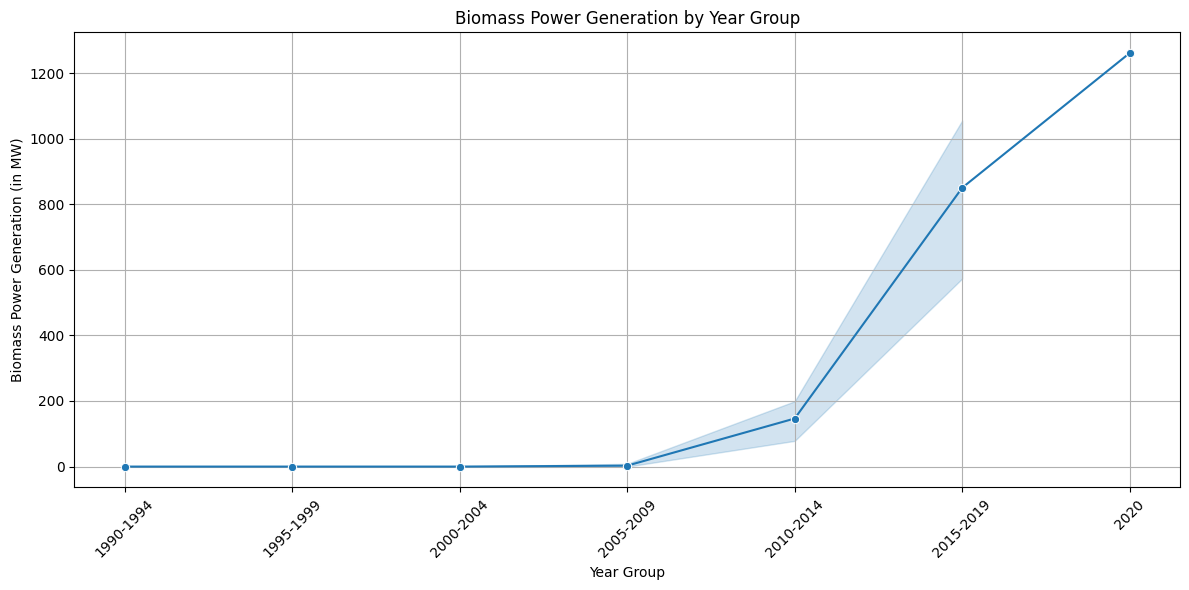

In [8]:
## Visualization Year Group Line Plot Biomass
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Biomass', marker='o')
plt.title('Biomass Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Biomass Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

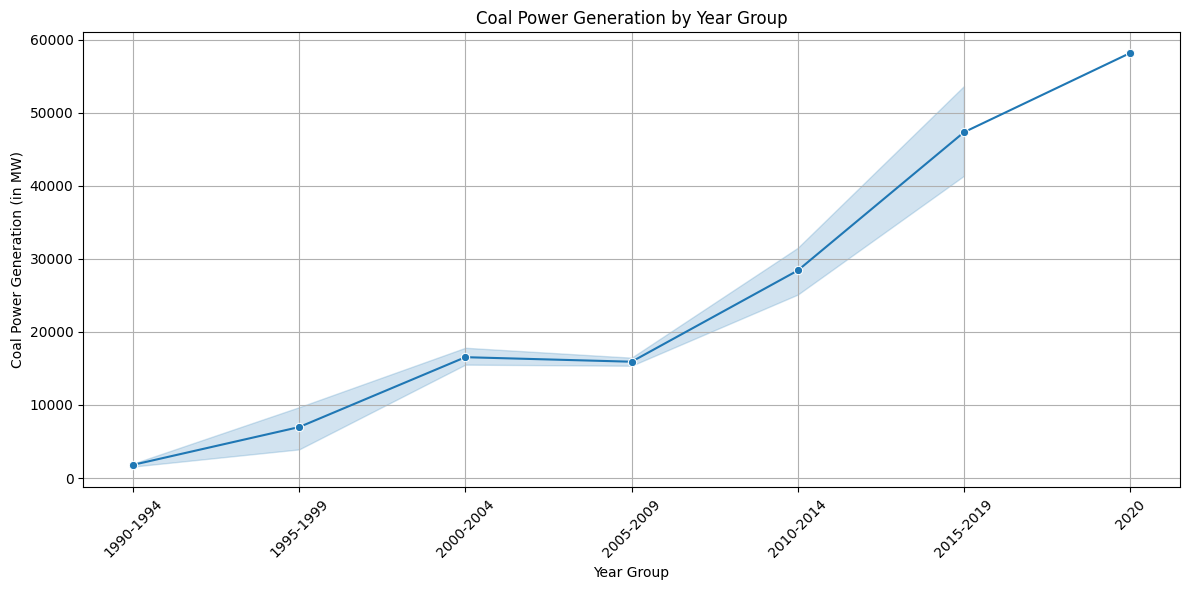

In [9]:
## Visualization Year Group Line Plot Coal
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Coal', marker='o')
plt.title('Coal Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Coal Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

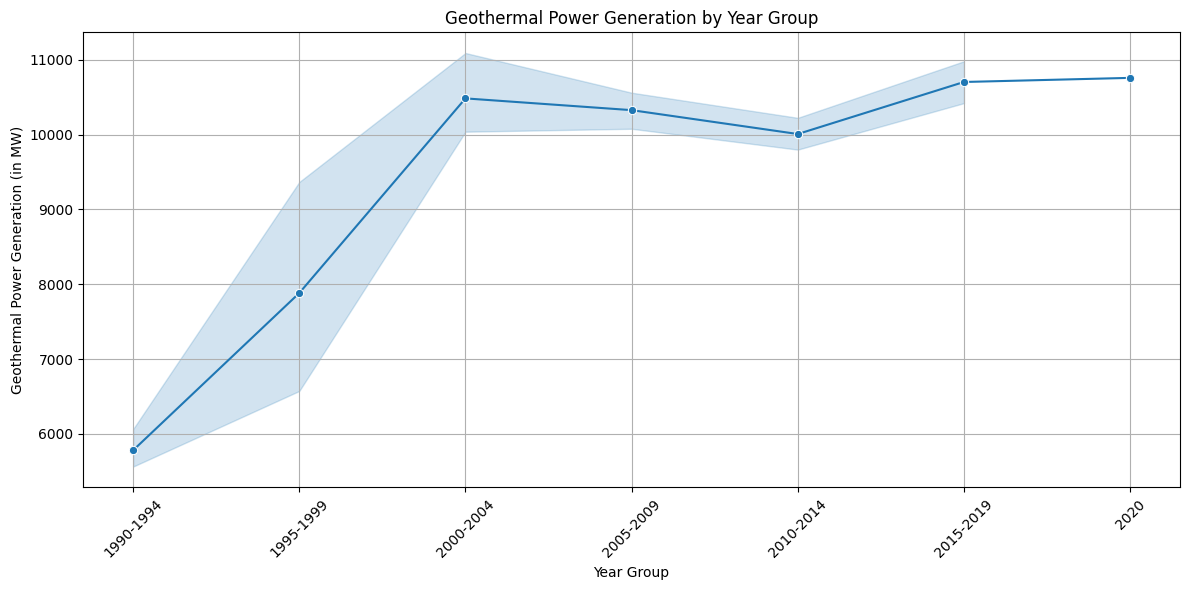

In [10]:
## Visualization Year Group Line Plot Geothermal
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Geothermal', marker='o')
plt.title('Geothermal Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Geothermal Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

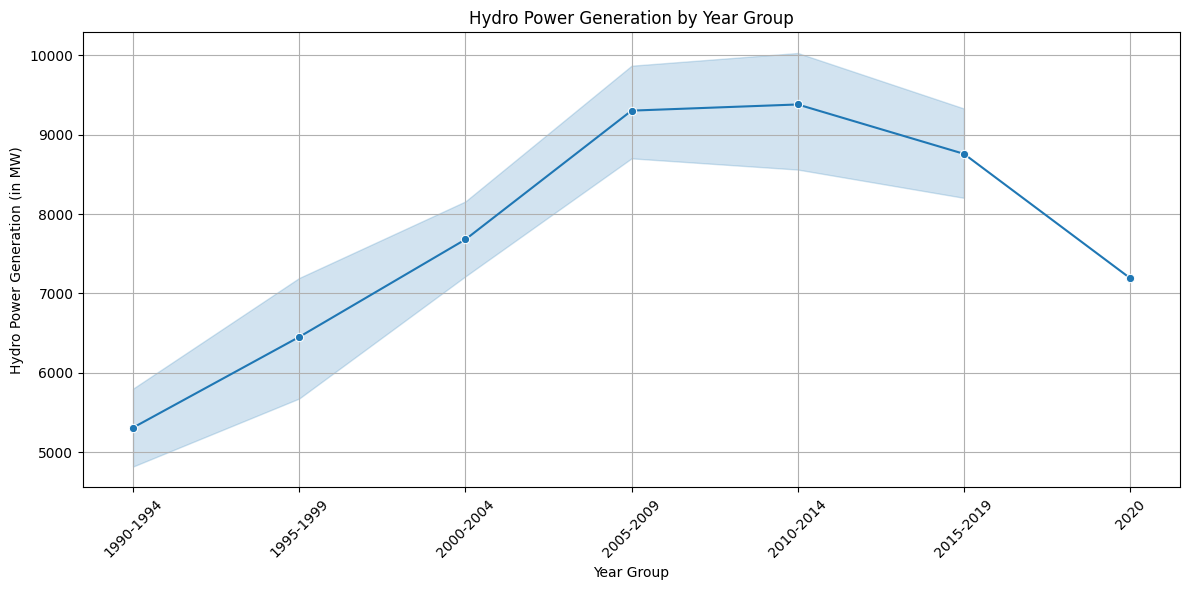

In [11]:
## Visualization Year Group Line Plot Hydro
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Hydro', marker='o')
plt.title('Hydro Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Hydro Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

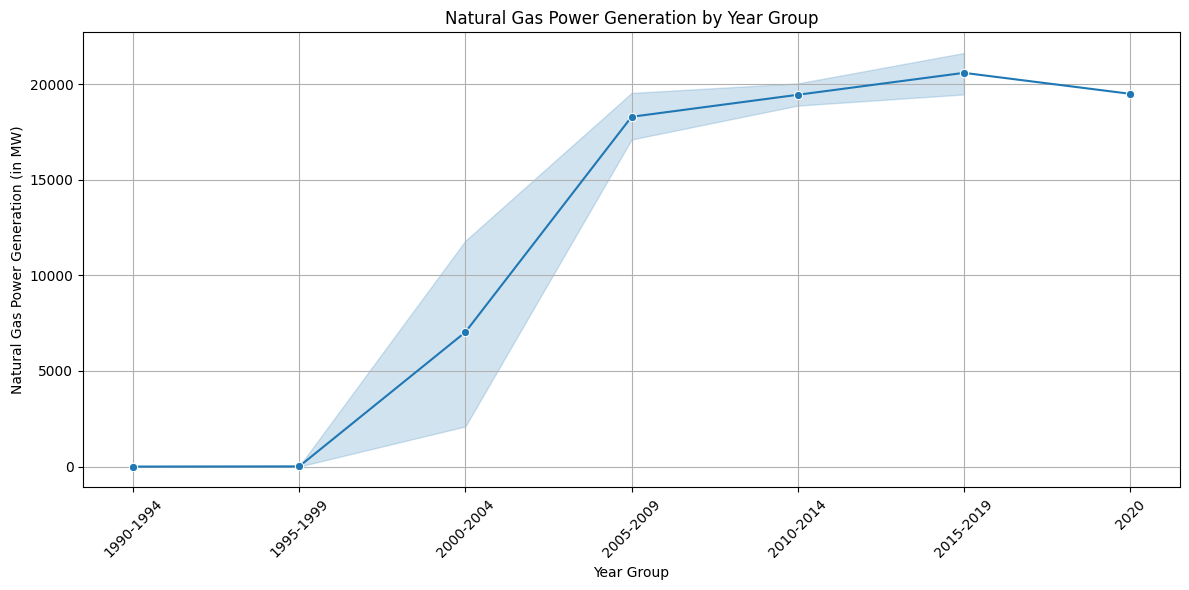

In [12]:
## Visualization Year Group Line Plot Natural Gas
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Natural Gas', marker='o')
plt.title('Natural Gas Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Natural Gas Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

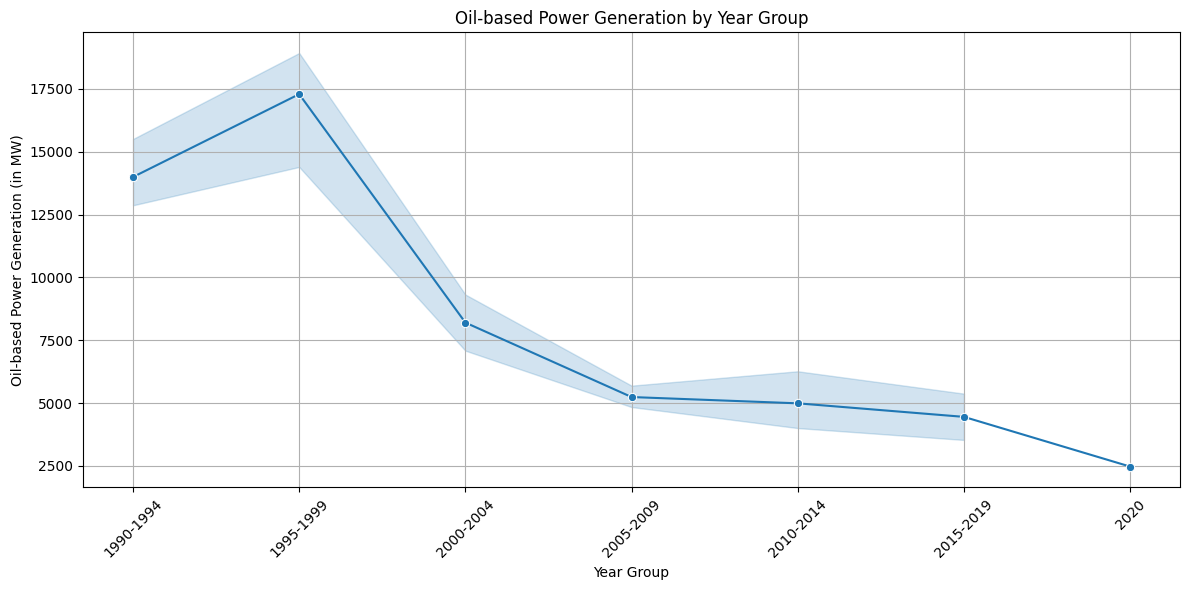

In [13]:
## Visualization Year Group Line Plot Oil-based
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Oil-based', marker='o')
plt.title('Oil-based Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Oil-based Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

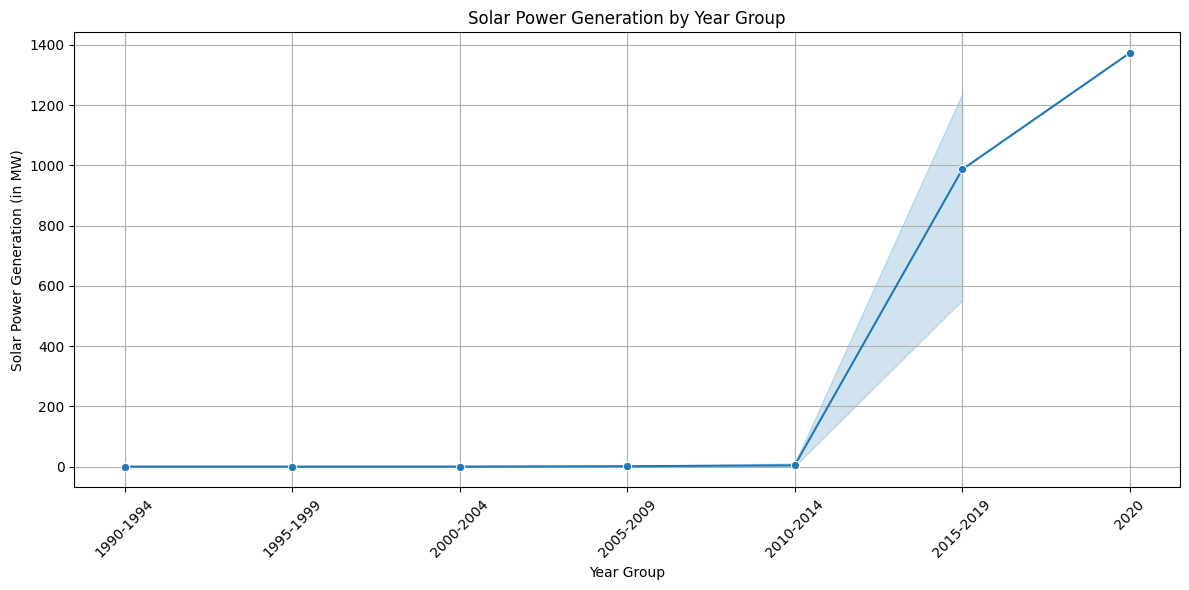

In [14]:
## Visualization Year Group Line Plot Solar
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Solar', marker='o')
plt.title('Solar Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Solar Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

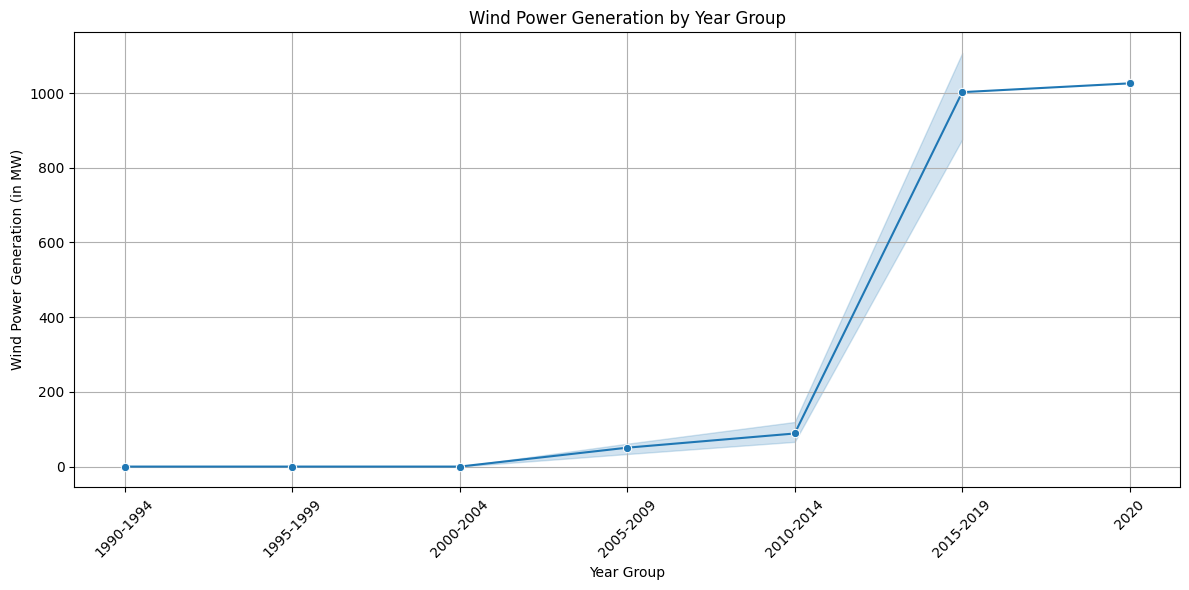

In [15]:
## Visualization Year Group Line Plot Wind
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Wind', marker='o')
plt.title('Wind Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Wind Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Overall Trends and Composition

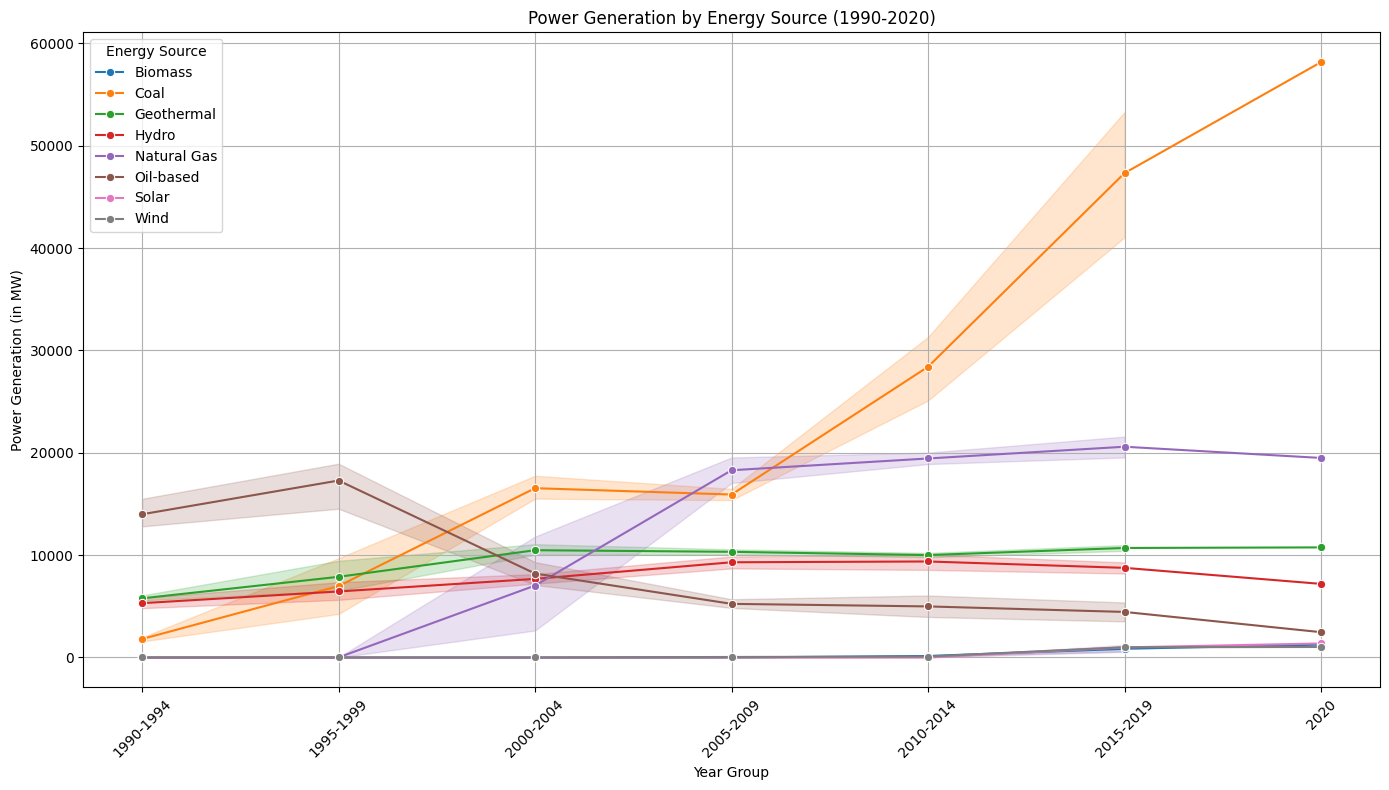

In [16]:
### Compare all energy sources in a single plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='Year Group', y='Biomass', marker='o', label='Biomass')
sns.lineplot(data=df, x='Year Group', y='Coal', marker='o', label='Coal')
sns.lineplot(data=df, x='Year Group', y='Geothermal', marker='o', label='Geothermal')
sns.lineplot(data=df, x='Year Group', y='Hydro', marker='o', label='Hydro')
sns.lineplot(data=df, x='Year Group', y='Natural Gas', marker='o', label='Natural Gas')
sns.lineplot(data=df, x='Year Group', y='Oil-based', marker='o', label='Oil-based')
sns.lineplot(data=df, x='Year Group', y='Solar', marker='o', label='Solar')
sns.lineplot(data=df, x='Year Group', y='Wind', marker='o', label='Wind')
plt.title('Power Generation by Energy Source (1990-2020)')
plt.xlabel('Year Group')
plt.ylabel('Power Generation (in MW)')
plt.xticks(rotation=45)
plt.legend(title='Energy Source')
plt.grid()
plt.tight_layout()
plt.show()


### Comparing source of Energy from 1990 and 2020

- From 1990 Oil-Based was the highest source of energy in the Philippines
- While on Year 2020 Coal is the highest source of energy in the Philippines with over 58,000 points
- Hydro and Geothermal power have remained remarkably stable and independent contributors throughout the entire period.

### Line Plot for Grand Total

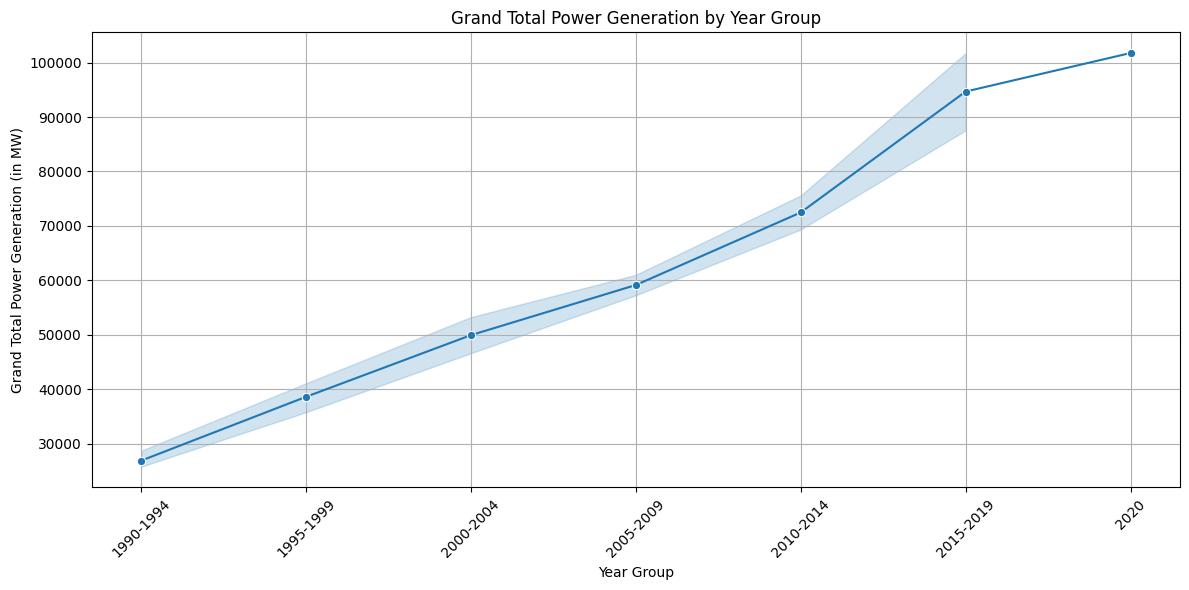

In [17]:
### Line Plot for Grand Total
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year Group', y='Grand Total', marker='o')
plt.title('Grand Total Power Generation by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Grand Total Power Generation (in MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

This shows that the energy production in the Philippines is increasing over time

## Trend Comparisson for first decade (1990-2009) and (2010-2020)

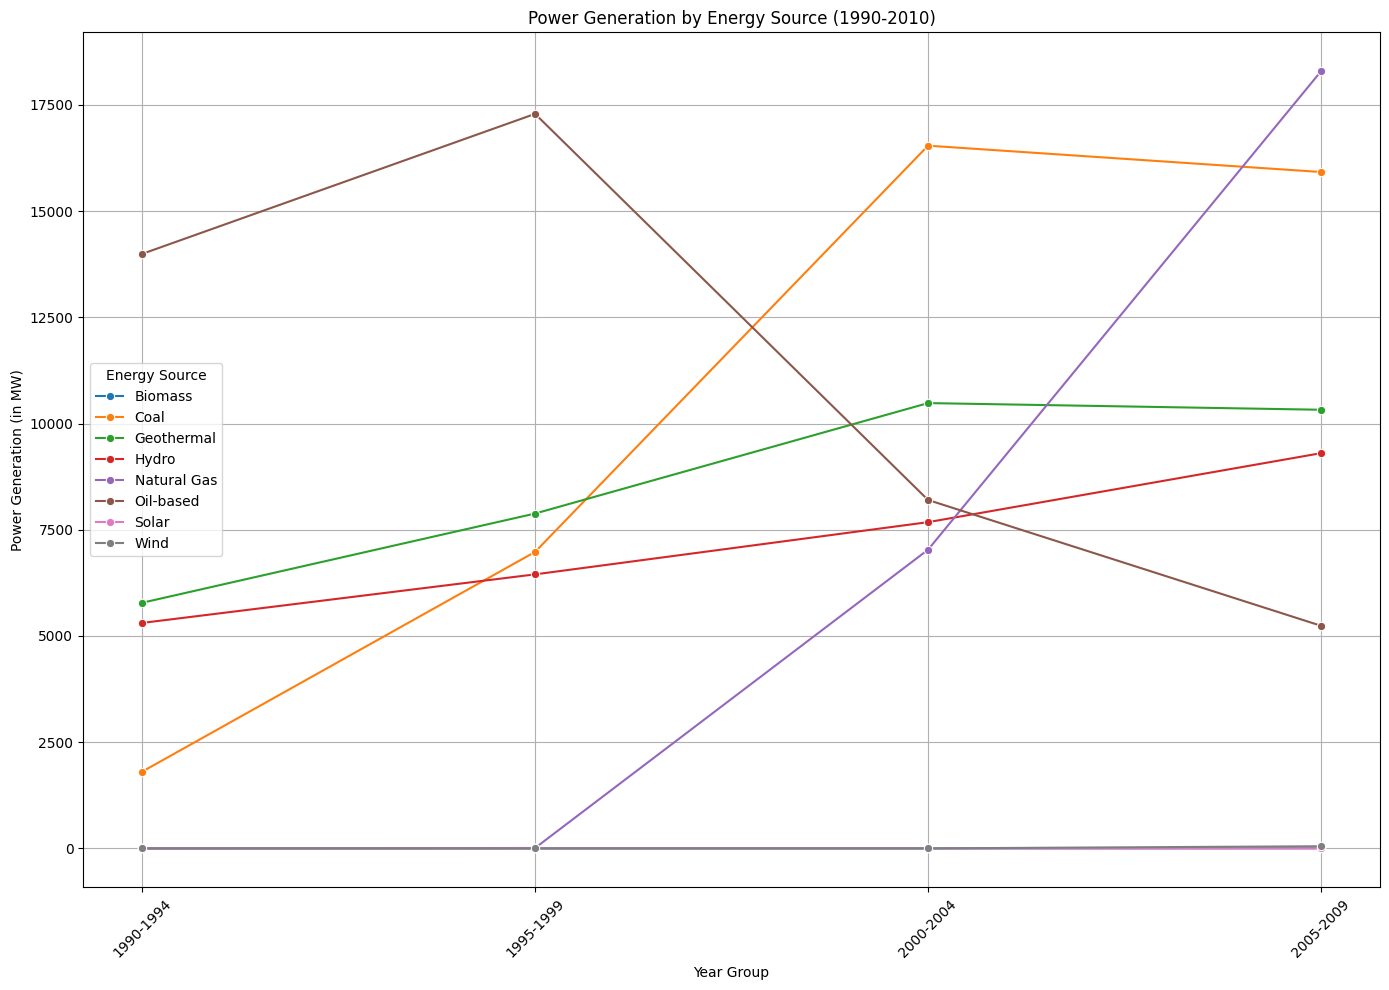

In [ ]:
### Compare all energy sources in a single plot from 1990 to 2009
plt.figure(figsize=(14, 10))
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])], 
                 x='Year Group', y='Biomass', marker='o', label='Biomass', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])], 
                 x='Year Group', y='Coal', marker='o', label='Coal', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Geothermal', marker='o', label='Geothermal', errorbar=None) 
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Hydro', marker='o', label='Hydro', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Natural Gas', marker='o', label='Natural Gas', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Oil-based', marker='o', label='Oil-based', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Solar', marker='o', label='Solar', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['1990-1994', '1995-1999', '2000-2004', '2005-2009'])],
                    x='Year Group', y='Wind', marker='o', label='Wind', errorbar=None)
plt.title('Power Generation by Energy Source (1990-2009)')
plt.xlabel('Year Group')
plt.ylabel('Power Generation (in MW)')
plt.xticks(rotation=45)
plt.legend(title='Energy Source')
plt.grid()
plt.tight_layout()
plt.show()

## Compare all energy sources in a single plot from 2010 to 2020

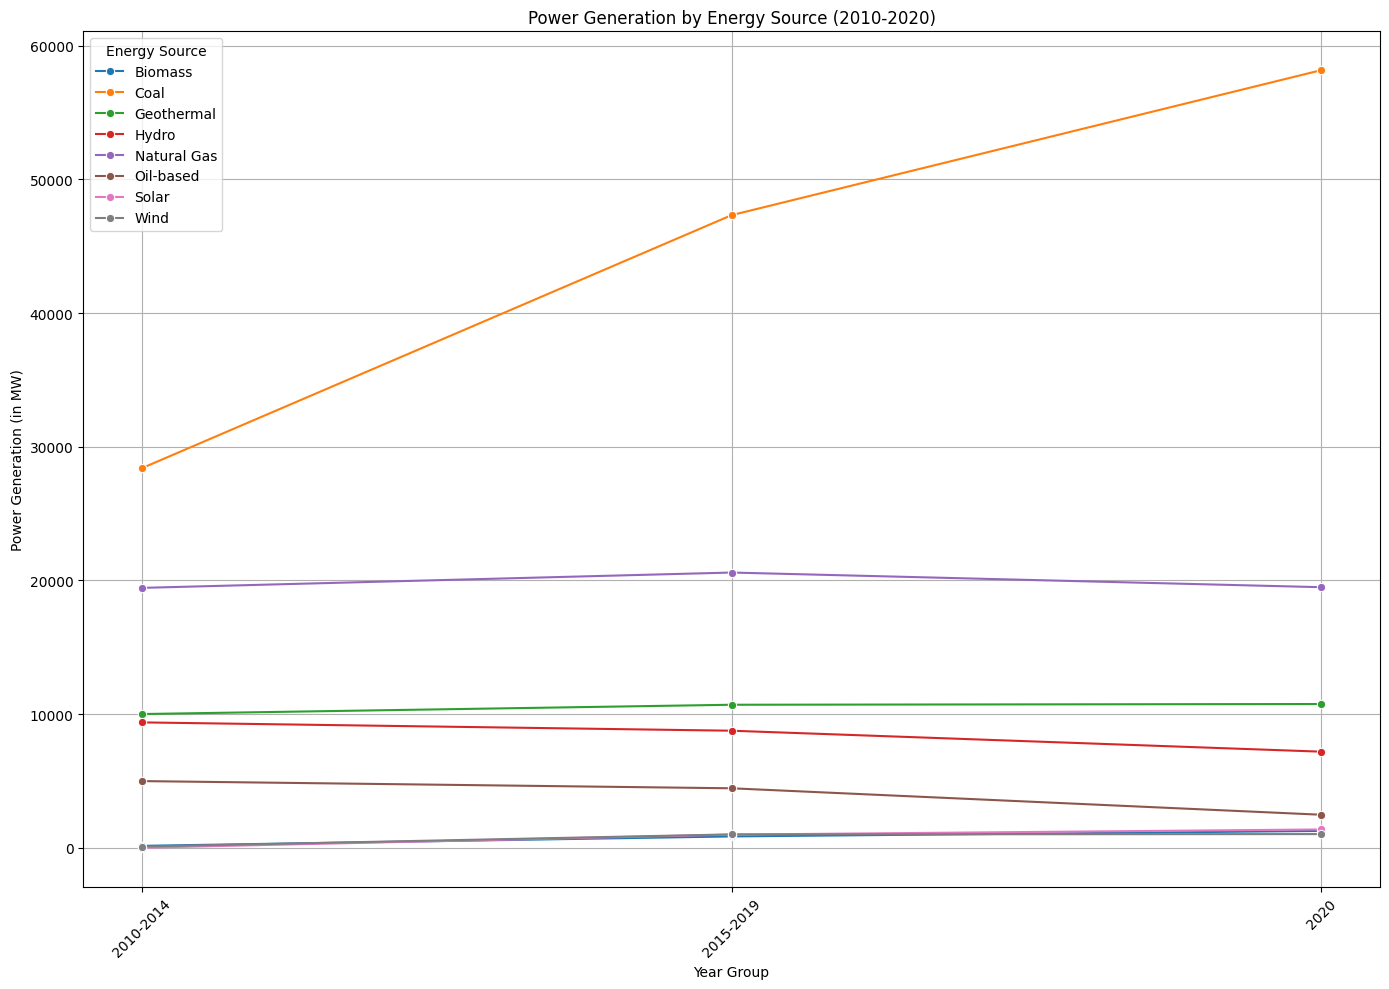

In [21]:
### Compare all energy sources in a single plot from 2010 to 2020
plt.figure(figsize=(14, 10))
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Biomass', marker='o', label='Biomass', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Coal', marker='o', label='Coal', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Geothermal', marker='o', label='Geothermal', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Hydro', marker='o', label='Hydro', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Natural Gas', marker='o', label='Natural Gas', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Oil-based', marker='o', label='Oil-based', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Solar', marker='o', label='Solar', errorbar=None)
sns.lineplot(data=df[df['Year Group'].isin(['2010-2014', '2015-2019', '2020'])],
                    x='Year Group', y='Wind', marker='o', label='Wind', errorbar=None)
plt.title('Power Generation by Energy Source (2010-2020)')
plt.xlabel('Year Group')
plt.ylabel('Power Generation (in MW)')
plt.xticks(rotation=45)
plt.legend(title='Energy Source')
plt.grid()
plt.tight_layout()
plt.show()

## Growth and Decline of Sources 

### Legacy vs. New Renewables

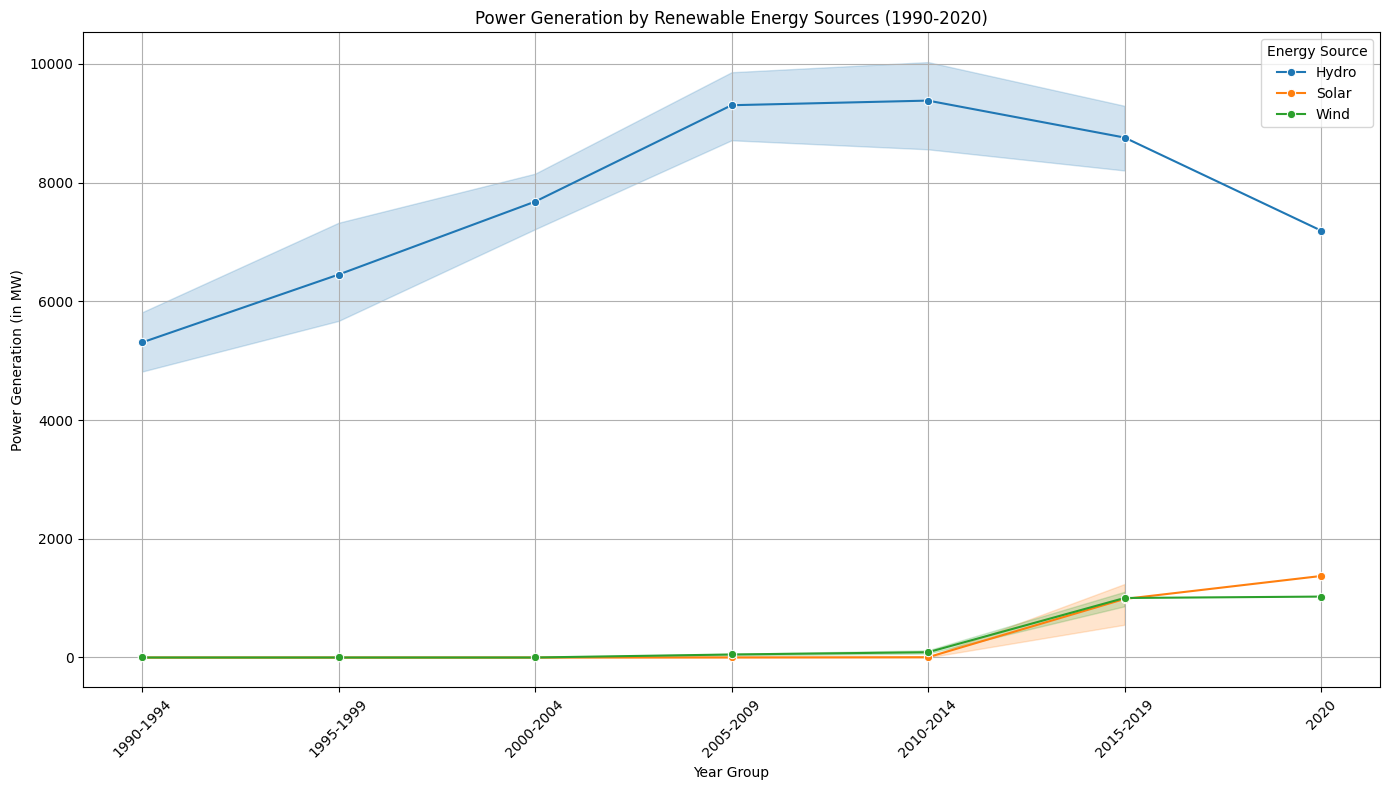

In [22]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=df, x='Year Group', y='Hydro', marker='o', label='Hydro')
sns.lineplot(data=df, x='Year Group', y='Solar', marker='o', label='Solar')
sns.lineplot(data=df, x='Year Group', y='Wind', marker='o', label='Wind')
plt.title('Power Generation by Renewable Energy Sources (1990-2020)')
plt.xlabel('Year Group')
plt.ylabel('Power Generation (in MW)')
plt.xticks(rotation=45)
plt.legend(title='Energy Source')
plt.grid()
plt.tight_layout()
plt.show()

- Hydro Power is still dominant when it comes to renewable energy but from 2010 it start declining because newer renewable energy like Solar and Windmild starting a uptrend. This shows that we are now adopting to new method of renewable energy

## Correlation of Energy Source

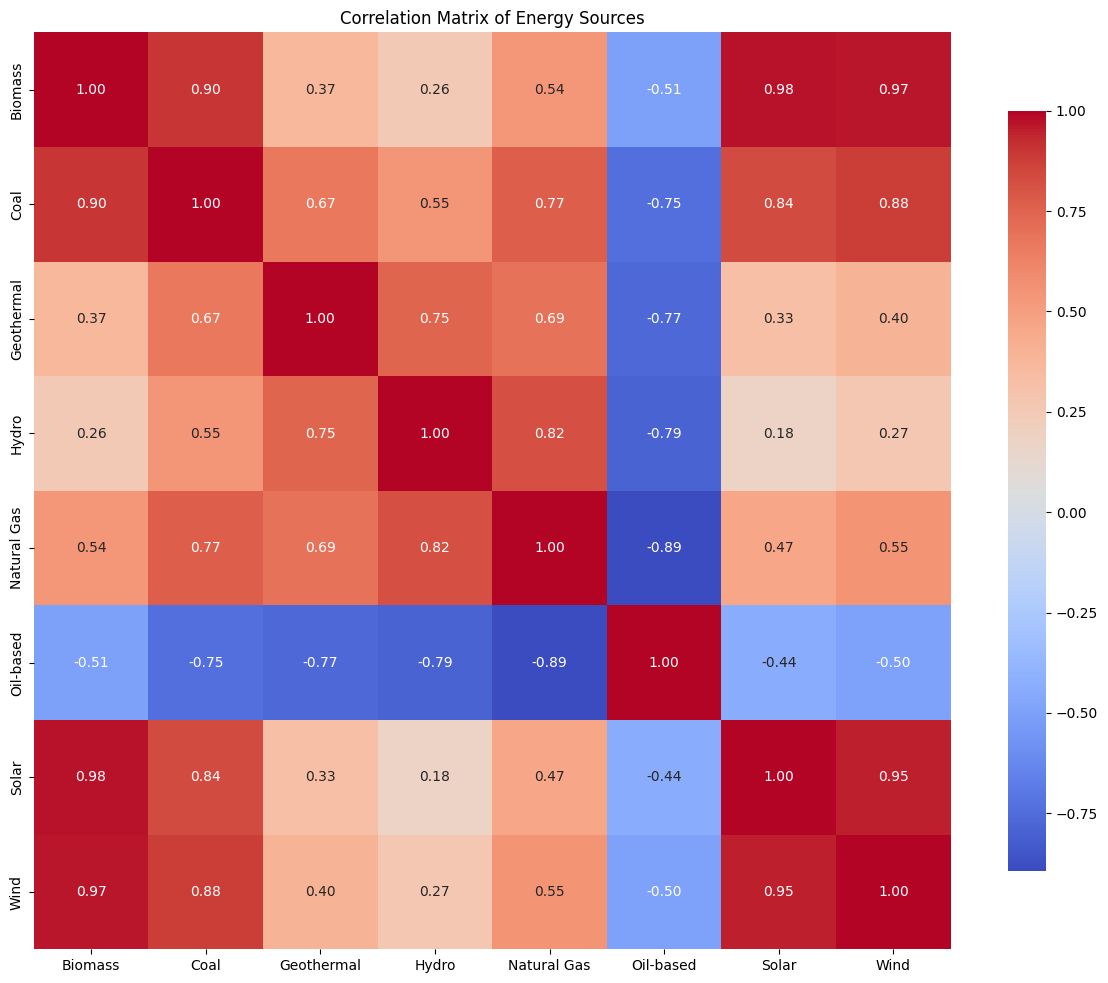

In [29]:
### Correlation Matrix
df_coor = df.drop(columns=['Years', 'Grand Total', 'Year Group'])  # Exclude non-numeric columns for correlation


plt.figure(figsize=(12, 10))
correlation_matrix = df_coor.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Energy Sources')
plt.tight_layout()
plt.show()

- Oil-Based have negative correlation to all source Energy, Meaning this is the decline usage of Oil-Based as source of Energy
- Biomass, Coal, Solar and Wind share positive strong correlation, means this sources grown together over the same period. 
- Solar also shows a strong positive correlation with sources like Wind, indicating it is part of the same recent growth trend for emerging renewable source of energy.